# Suicide Detection - Baseline Model
This notebook builds a baseline using TF-IDF and Logistic Regression.

              precision    recall  f1-score   support

           0       0.92      0.94      0.93     23208
           1       0.94      0.92      0.93     23207

    accuracy                           0.93     46415
   macro avg       0.93      0.93      0.93     46415
weighted avg       0.93      0.93      0.93     46415



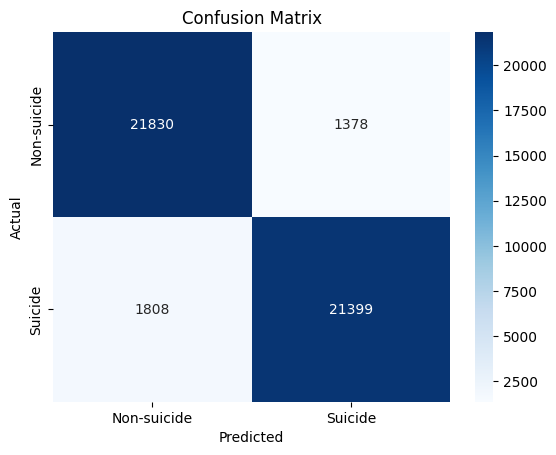

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("Suicide_Detection.csv")
df = df.dropna()
df['label'] = df['class'].map({'non-suicide': 0, 'suicide': 1})

# train-test split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# predict
y_pred = model.predict(X_test_vec)

# evaluate
print(classification_report(y_test, y_pred))
conf_mat = confusion_matrix(y_test, y_pred)

# plot confusion matrix
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-suicide', 'Suicide'], yticklabels=['Non-suicide', 'Suicide'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()